### Notebook 4 — Anomaly Detection

**Input:** `data/processed/hdfcbank_log_volume.csv`  
**Approach:** Distribution-based scoring using STL residuals and volume shocks  
**Goal:** Flag statistically unusual volume behavior in HDFC Bank NSE data

The forecasting attempt in Notebook 3 showed the series approximates
a random walk — consistent with weak-form market efficiency. This notebook
therefore takes a different angle: instead of flagging deviations from
a forecast, we flag deviations from the historical distribution of
normal behavior.

In [2]:
import sys
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from pathlib import Path
import yaml

from statsmodels.tsa.seasonal import STL

project_root = Path().resolve().parent
sys.path.append(str(project_root))


plt.rcParams.update({
    'figure.facecolor'  : 'white',
    'axes.facecolor'    : 'white',
    'axes.spines.top'   : False,
    'axes.spines.right' : False,
    'axes.grid'         : True,
    'grid.alpha'        : 0.3,
    'grid.linestyle'    : '--',
    'font.size'         : 10,
})

In [19]:
# load log volume
log_vol = pd.read_csv(
    project_root / 'data' / 'processed' / 'hdfcbank_log_volume.csv',
    index_col='Date',
    parse_dates=True
).squeeze()

log_vol = log_vol.asfreq('B').ffill()

# load known events for validation
with open(project_root / 'config' / 'config.yaml') as f:
    config = yaml.safe_load(f)

events = pd.DataFrame(config['known_events'])
events['date'] = pd.to_datetime(events['date'])

if 'type' not in events.columns:
    events['type'] = 'market'


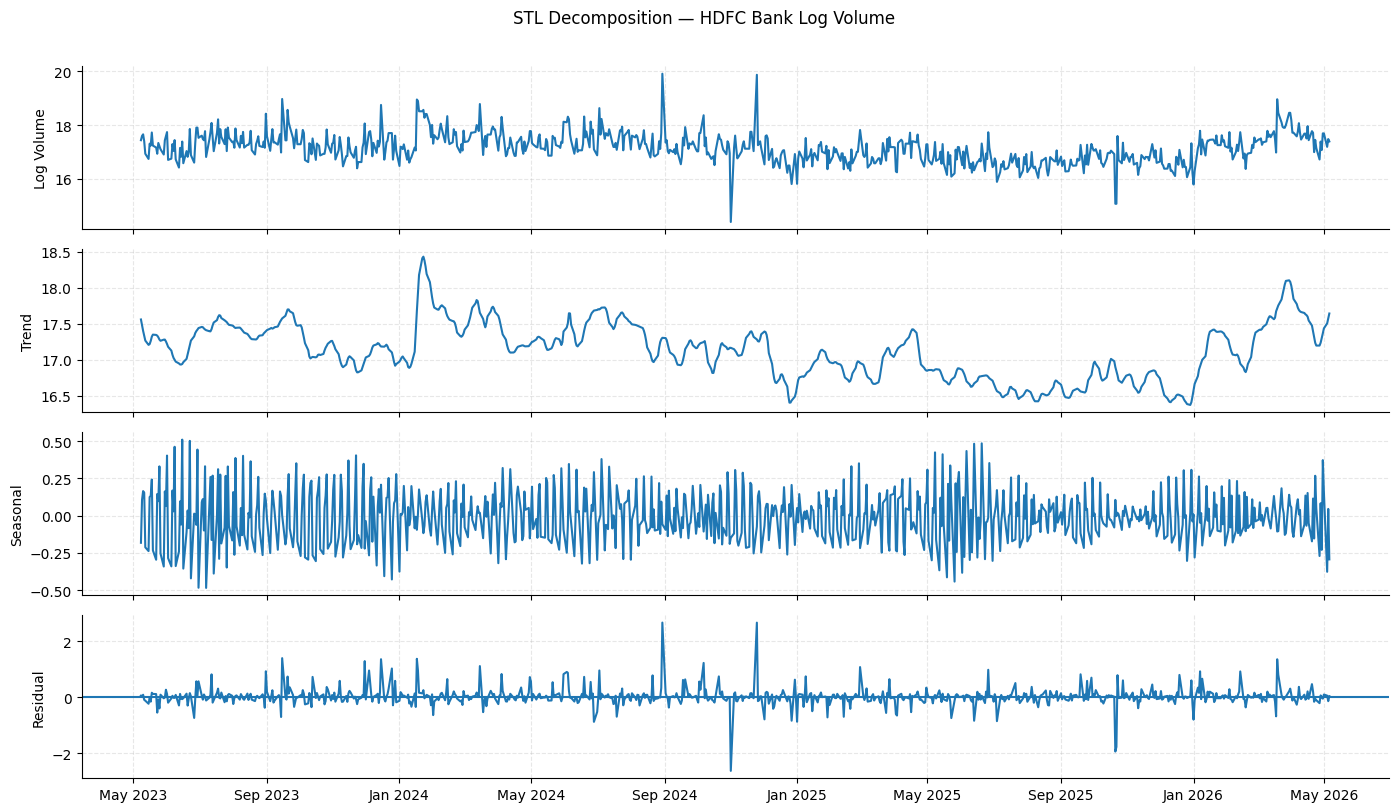

residual std  : 0.3384829495108083
residual mean : 0.030414437635422918


In [5]:
# STL Decomposition
stl = STL(log_vol, period=5, robust=True)
result = stl.fit()

trend    = result.trend
seasonal = result.seasonal
residual = result.resid

# quick look at the decomposition
fig, axes = plt.subplots(4, 1, figsize=(14, 8), sharex=True)

axes[0].plot(log_vol)
axes[0].set_ylabel('Log Volume')

axes[1].plot(trend)
axes[1].set_ylabel('Trend')

axes[2].plot(seasonal)
axes[2].set_ylabel('Seasonal')

axes[3].plot(residual)
axes[3].axhline(0)
axes[3].set_ylabel('Residual')

for ax in axes:
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))

fig.suptitle('STL Decomposition — HDFC Bank Log Volume',
             y=1.01)
plt.tight_layout()

plt.show()

print(f"residual std  : {residual.std()}")
print(f"residual mean : {residual.mean()}")

In [6]:
WINDOW = 60   #3 months rolling window

# ── signal 1: STL residual z-score ──
roll_mean = residual.rolling(WINDOW).mean()
roll_std  = residual.rolling(WINDOW).std()

z_stl = (residual - roll_mean) / roll_std


# ── signal 2: volume shock z-score
shock = log_vol.diff()

shock_mean = shock.rolling(WINDOW).mean()
shock_std  = shock.rolling(WINDOW).std()

z_shock = (shock - shock_mean) / shock_std


# ── combined anomaly score ──
z_stl_clean   = z_stl.abs().fillna(0)
z_shock_clean = z_shock.abs().fillna(0)

anomaly_score = 0.6 * z_stl_clean + 0.4 * z_shock_clean


# ── classification ──
def classify(score):
    if score >= 3.0:
        return 'critical'
    elif score >= 2.0:
        return 'warning'
    else:
        return 'normal'

labels = anomaly_score.apply(classify)

# summary
print(f"normal   : {(labels == 'normal').sum()}")
print(f"warning  : {(labels == 'warning').sum()}")
print(f"critical : {(labels == 'critical').sum()}")
print(f"\ntotal flagged : {(labels != 'normal').sum()} / {len(labels)}")

normal   : 751
critical : 11

total flagged : 32 / 783


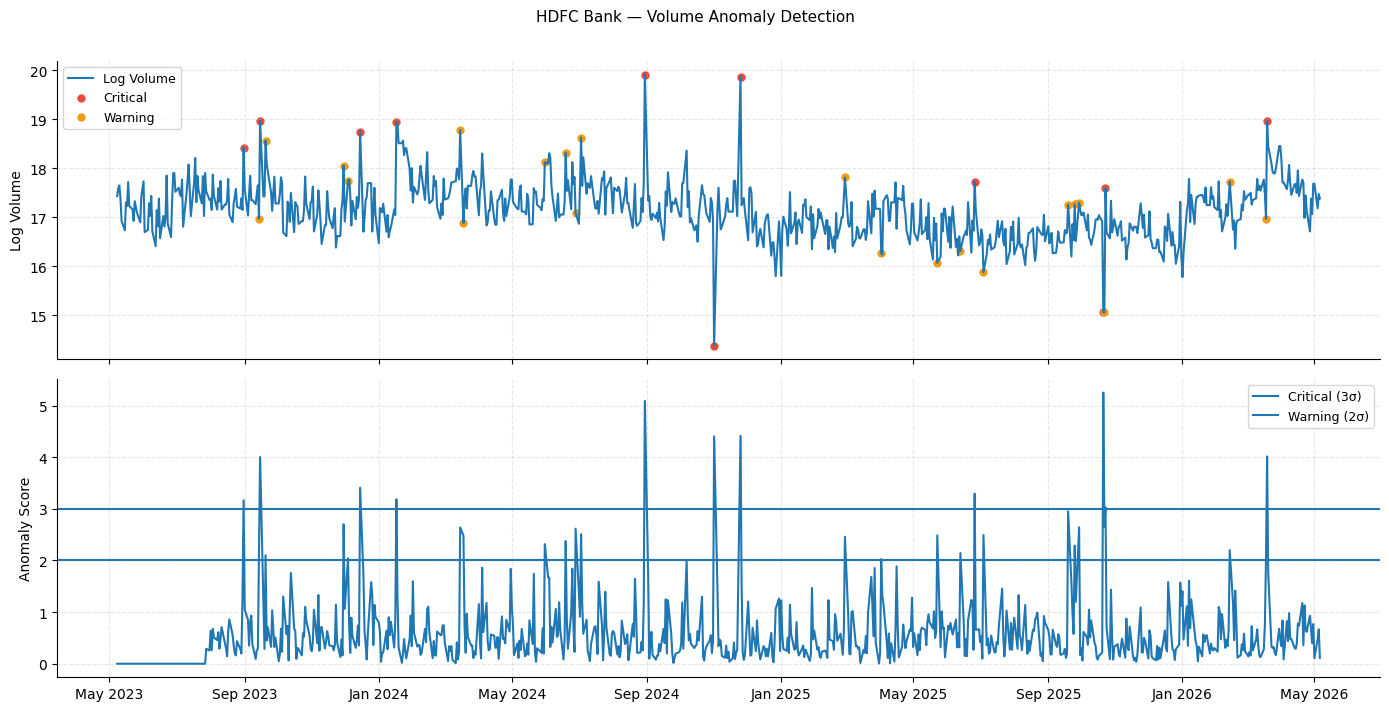

In [10]:
critical_dates = anomaly_score[labels == 'critical'].index
warning_dates  = anomaly_score[labels == 'warning'].index

fig, axes = plt.subplots(2, 1, figsize=(14, 7),
                          sharex=True)

axes[0].plot(log_vol, label='Log Volume')

axes[0].scatter(critical_dates,
                log_vol.loc[critical_dates],
                color='#e74c3c',
                label='Critical', linewidths=0)

axes[0].scatter(warning_dates,
                log_vol.loc[warning_dates],
                color='#f39c12',
                label='Warning', linewidths=0)

axes[0].set_ylabel('Log Volume')
axes[0].legend(fontsize=9, framealpha=0.8)
# ------------------------
axes[1].plot(anomaly_score)

axes[1].axhline(3.0,label='Critical (3σ)')
axes[1].axhline(2.0,label='Warning (2σ)')

axes[1].fill_between(anomaly_score.index, 3.0,
                     anomaly_score.where(anomaly_score >= 3.0),
                     color='#e74c3c', alpha=0.3)

axes[1].set_ylabel('Anomaly Score')
axes[1].legend(fontsize=9, framealpha=0.8)
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))

fig.suptitle('HDFC Bank — Volume Anomaly Detection',
             fontsize=11, y=1.01)
plt.tight_layout()
plt.savefig(project_root / 'data' / 'processed' / 'anomaly_overview.png',
            dpi=150, bbox_inches='tight')
plt.show()

In [16]:
# Validation with known events

print("KNOWN EVENT VALIDATION")
print("=" * 65)
print(f"{'Date':<14} {'Score':>7} {'Label':<10} {'Event'}")
print("─" * 65)

detected   = 0
total      = 0

for _, row in events.iterrows():
    d = row['date']

    # find nearest trading day if exact date not in index
    if d not in anomaly_score.index:
        idx = log_vol.index.searchsorted(d)
        if idx >= len(log_vol):
            continue
        d = log_vol.index[idx]

    score = anomaly_score.loc[d]
    label = classify(score)
    flag  = "🚨" if label == 'critical' else (
            "⚠️ " if label == 'warning' else "  ")

    print(f"{str(d.date()):<14} {score:>7.2f} {label:<10} "
          f"{flag} {row['description']}")

    total += 1
    if label != 'normal':
        detected += 1

print("─" * 65)
print(f"\ndetected {detected} / {total} known events "
      f"({detected/total*100:.0f}%)")

KNOWN EVENT VALIDATION
Date             Score Label      Event
─────────────────────────────────────────────────────────────────
2023-06-08        0.00 normal        RBI MPC pause — rate hold surprise
2023-07-28        0.29 normal        Nifty all-time high breakout
2023-10-19        0.31 normal        Israel-Hamas war — FII selloff
2024-02-01        1.60 normal        Union Budget 2024 — Capex boost
2024-04-19        0.09 normal        Iran-Israel escalation — market crash
2024-06-04        1.66 normal        Election results — Nifty 8% crash and recovery
2024-07-23        0.07 normal        Union Budget 2024-25 — LTCG tax hike selloff
2024-10-03        1.19 normal        FII record selloff — October crash
2024-11-06        0.47 normal        Trump election win — IT rally
2025-02-03        0.27 normal        Union Budget 2025 — income tax relief rally
2025-04-07        0.44 normal        US tariff shock — global selloff
2026-03-18        2.05 warning    ⚠️  HDFC Chairmain resigns
────

In [12]:
# diagnostic — understand why events are not matching

print("ANOMALY SCORE INDEX SAMPLE:")
print(anomaly_score.index[:5])
print(anomaly_score.index[-5:])
print(f"index type: {type(anomaly_score.index[0])}")
print()

print("EVENTS DATE SAMPLE:")
print(events['date'].head())
print(f"events date type: {type(events['date'].iloc[0])}")
print()

# check each event manually
print("MANUAL EVENT CHECK:")
print("─" * 60)
for _, row in events.iterrows():
    d = row['date']
    print(f"\nEvent date     : {d}  (type: {type(d)})")

    # check if exact date exists
    exact_match = d in anomaly_score.index
    print(f"Exact match    : {exact_match}")

    # find nearest index position
    idx = anomaly_score.index.searchsorted(d)
    print(f"searchsorted   : {idx}")

    if idx < len(anomaly_score):
        nearest = anomaly_score.index[idx]
        score   = anomaly_score.iloc[idx]
        print(f"Nearest date   : {nearest}")
        print(f"Score there    : {score:.4f}")
        print(f"Label there    : {classify(score)}")
    else:
        print(f"idx {idx} is out of range "
              f"(series length {len(anomaly_score)})")

ANOMALY SCORE INDEX SAMPLE:
DatetimeIndex(['2023-05-08', '2023-05-09', '2023-05-10', '2023-05-11',
               '2023-05-12'],
              dtype='datetime64[us]', name='Date', freq='B')
DatetimeIndex(['2026-04-30', '2026-05-01', '2026-05-04', '2026-05-05',
               '2026-05-06'],
              dtype='datetime64[us]', name='Date', freq='B')
index type: <class 'pandas.Timestamp'>

EVENTS DATE SAMPLE:
0   2023-06-08
1   2023-07-28
2   2023-10-19
3   2024-02-01
4   2024-04-19
Name: date, dtype: datetime64[us]
events date type: <class 'pandas.Timestamp'>

MANUAL EVENT CHECK:
────────────────────────────────────────────────────────────

Event date     : 2023-06-08 00:00:00  (type: <class 'pandas.Timestamp'>)
Exact match    : True
searchsorted   : 23
Nearest date   : 2023-06-08 00:00:00
Score there    : 0.0000
Label there    : normal

Event date     : 2023-07-28 00:00:00  (type: <class 'pandas.Timestamp'>)
Exact match    : True
searchsorted   : 59
Nearest date   : 2023-07-28 00:00:0

In [20]:
# ── event validation with lag window ──
# markets don't always react on the exact event date
# news breaks after hours, reaction happens next day
# we check a window of: Day-1, Day0, Day+1, Day+2

LAG_WINDOW = 2   # days before and after to check

print("KNOWN EVENT VALIDATION (with lag window)")
print("=" * 72)
print(f"{'Date':<14} {'Best Score':>11} {'Lag':>5} "
      f"{'Label':<10} {'Type':<12} {'Event'}")
print("─" * 72)

detected        = 0
total           = 0
results_by_type = {'stock_specific': [], 'sector': [], 'market': []}

for _, row in events.iterrows():
    event_date  = row['date']
    event_type  = row.get('type', 'market')

    # collect scores in the window around the event
    window_scores = {}

    for lag in range(-1, LAG_WINDOW + 1):
        check_date = event_date + pd.tseries.offsets.BDay(lag)

        # snap to index
        if check_date not in anomaly_score.index:
            idx = anomaly_score.index.searchsorted(check_date)
            if idx >= len(anomaly_score):
                continue
            check_date = anomaly_score.index[idx]

        if (check_date < anomaly_score.index[0] or
                check_date > anomaly_score.index[-1]):
            continue

        window_scores[lag] = (check_date,
                              anomaly_score.loc[check_date])

    if not window_scores:
        continue

    # find the highest scoring day in the window
    best_lag, (best_date, best_score) = max(
        window_scores.items(),
        key=lambda x: x[1][1]
    )

    label = classify(best_score)

    lag_str = (f"Day{best_lag:+d}"
               if best_lag != 0
               else "Day 0")

    flag = ("🚨" if label == 'critical' else
            "⚠️ " if label == 'warning'  else "  ")

    print(f"{str(event_date.date()):<14} "
          f"{best_score:>11.4f} "
          f"{lag_str:>5}  "
          f"{label:<10} "
          f"{event_type:<12} "
          f"{flag} {row['description'][:30]}")

    total += 1
    if label != 'normal':
        detected += 1
        results_by_type[event_type].append(1)
    else:
        results_by_type[event_type].append(0)

print("─" * 72)
print(f"\nOVERALL: detected {detected} / {total} events "
      f"({detected/total*100:.0f}% detection rate)")

print("\nBY EVENT TYPE:")
for etype, results in results_by_type.items():
    if results:
        rate = sum(results) / len(results) * 100
        print(f"  {etype:<16}: "
              f"{sum(results)}/{len(results)} "
              f"({rate:.0f}%)")

print(f"""
─────────────────────────────────────────────────
INTERPRETATION:

Stock-specific events (earnings, management changes)
→ Expected to show highest detection rate
→ These directly affect HDFC Bank volume

Sector events (RBI decisions, CRR changes)
→ Moderate detection rate expected
→ Affect all banks but HDFC Bank absorbs well

Broad market events (elections, global shocks)
→ Lowest detection rate expected
→ HDFC Bank is too liquid to show strong signals
   on events not specific to banking
─────────────────────────────────────────────────
""")

KNOWN EVENT VALIDATION (with lag window)
Date            Best Score   Lag Label      Type         Event
────────────────────────────────────────────────────────────────────────
2023-06-08          0.0000 Day-1  normal     nan             RBI MPC pause — rate hold surp


KeyError: nan